In [1]:
import pandas as pd
import numpy as np
import sqlite3

conn = sqlite3.connect("../database/mutual_fund.db")

nav_df = pd.read_sql("""
SELECT amfi_code, date, nav
FROM fact_nav
""", conn)

nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])

In [5]:
#Compute Daily Returns

In [3]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [6]:
nav_df.to_csv("returns_computed.csv", index=False)

In [7]:
#Check Return Distribution

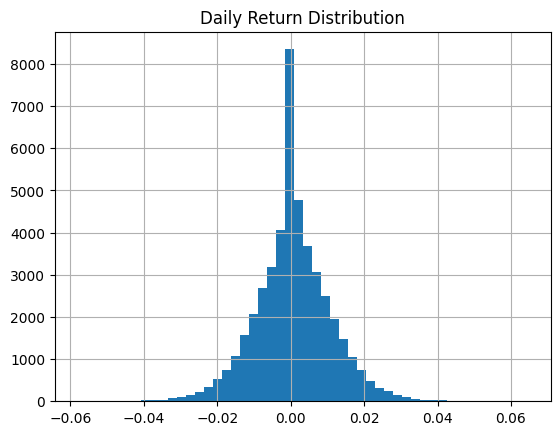

In [8]:
import matplotlib.pyplot as plt

nav_df["daily_return"].hist(bins=50)
plt.title("Daily Return Distribution")
plt.show()

In [9]:
#Compute CAGR

In [10]:
cagr_list = []

for fund, grp in nav_df.groupby("amfi_code"):
    start_nav = grp["nav"].iloc[0]
    end_nav = grp["nav"].iloc[-1]

    years = (
        (grp["date"].max() - grp["date"].min()).days
    ) / 365

    cagr = (end_nav/start_nav)**(1/years)-1

    cagr_list.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code","cagr"]
)

cagr_df.to_csv("cagr_report.csv",index=False)

In [12]:
#Sharpe Ratio

In [13]:
rf = 0.065

sharpe_list = []

for fund, grp in nav_df.groupby("amfi_code"):

    ret = grp["daily_return"].dropna()

    annual_return = ret.mean()*252
    annual_std = ret.std()*np.sqrt(252)

    sharpe = (annual_return-rf)/annual_std

    sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code","sharpe_ratio"]
)

In [14]:
#Sortino Ratio

In [15]:
sortino_list = []

for fund, grp in nav_df.groupby("amfi_code"):

    ret = grp["daily_return"].dropna()

    downside = ret[ret < 0]

    downside_std = downside.std()*np.sqrt(252)

    annual_return = ret.mean()*252

    sortino = (annual_return-rf)/downside_std

    sortino_list.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code","sortino_ratio"]
)

In [16]:
#Maximum Drawdown

In [17]:
mdd_list = []

for fund, grp in nav_df.groupby("amfi_code"):

    running_max = grp["nav"].cummax()

    drawdown = (
        grp["nav"]/running_max
    ) - 1

    max_dd = drawdown.min()

    mdd_list.append([fund,max_dd])

mdd_df = pd.DataFrame(
    mdd_list,
    columns=["amfi_code","max_drawdown"]
)

In [19]:
import pandas as pd

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [21]:
#Top 10 Funds by Sharpe Ratio

In [20]:
top_sharpe = (
    performance
    .sort_values("sharpe_ratio", ascending=False)
    .head(10)
)

top_sharpe[["scheme_name","sharpe_ratio"]]

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [22]:
#Top 10 Funds by Alpha

In [23]:
performance.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,0.95,0.98,1.57,16.0,-19.50,35012,1.45,5,Moderately High
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
37,149322,DSP Top 100 Equity Fund - Regular - Growth,DSP Mutual Fund,Large Cap,Regular,11.96,12.82,12.35,11.00,1.82,0.91,0.92,1.63,14.0,-21.70,41828,1.54,5,Moderate
18,118635,Nippon India ETF Nifty 50 BeES,Nippon India MF,Index/ETF,Direct,10.14,11.77,12.31,9.97,1.80,1.04,0.91,1.24,13.0,-26.75,20284,0.89,5,Moderate
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,1.00,0.96,1.37,16.0,-12.14,17912,1.64,5,Moderately High
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,0.99,0.91,1.55,16.0,-33.15,49046,1.52,5,Moderately High


In [24]:
#Best Funds by 3-Year Return

In [25]:
performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,0.98,0.80,1.23,25.0,-17.01,35124,1.52,4,Very High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High


In [26]:
# Lowest Drawdown Funds

In [27]:
performance.sort_values(
    "max_drawdown_pct",
    ascending=False
).head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,1.00,0.96,1.37,16.0,-12.14,17912,1.64,5,Moderately High
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
32,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,Regular,16.30,15.61,15.86,14.49,1.12,0.92,0.82,1.21,19.0,-13.43,41728,1.51,5,High
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High


In [28]:
scorecard = performance.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=False)

scorecard["score"] = (
    0.30*scorecard["return_rank"] +
    0.25*scorecard["sharpe_rank"] +
    0.20*scorecard["alpha_rank"] +
    0.15*scorecard["expense_rank"] +
    0.10*scorecard["drawdown_rank"]
)

scorecard = scorecard.sort_values("score")

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [30]:
import pandas as pd

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

scorecard = performance.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank()

scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=False)

scorecard["final_score"] = (
    scorecard["return_rank"] * 0.30 +
    scorecard["sharpe_rank"] * 0.25 +
    scorecard["alpha_rank"] * 0.20 +
    scorecard["expense_rank"] * 0.15 +
    scorecard["drawdown_rank"] * 0.10
)

scorecard = scorecard.sort_values("final_score")

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,final_score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,11.0,12.0,3.5,22.0,20.0,12.300
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,8.0,12.750
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,39116,0.74,5,Low,35.0,1.0,3.5,7.0,3.0,12.800
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,27953,0.56,3,Low,36.0,4.0,1.0,2.0,6.0,12.900
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,7.0,15.0,2.0,33.0,25.0,13.700
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,2.0,19.5,22.5,5.5,30.0,13.800
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,11361,1.46,5,Moderate,17.0,7.5,12.0,23.0,15.0,14.325
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,3.0,24.5,5.0,28.5,27.0,15.000
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,27623,0.60,3,Low,37.0,2.0,14.0,3.0,5.0,15.350
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,...,17912,1.64,5,Moderately High,13.0,15.0,8.0,39.5,7.0,15.875


In [31]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [32]:
#Top 10 Sharpe Ratio Chart

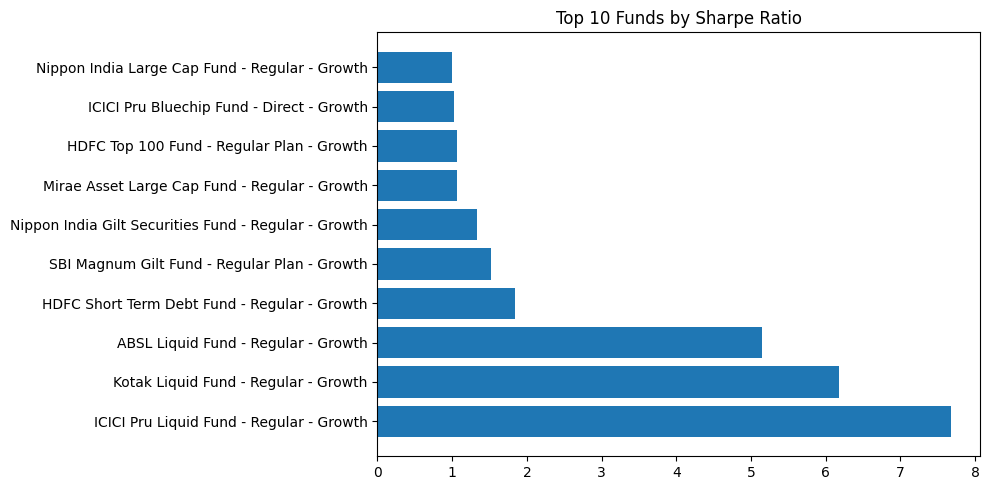

In [33]:
import matplotlib.pyplot as plt

top10 = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10["scheme_name"],
    top10["sharpe_ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.tight_layout()
plt.show()

In [34]:
# Top 10 Alpha Chart

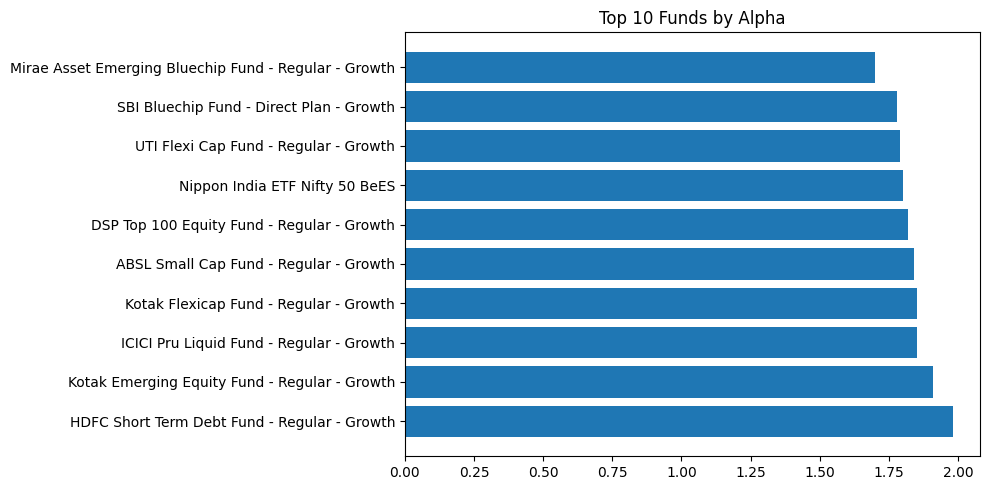

In [35]:
top_alpha = performance.sort_values(
    "alpha",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top_alpha["scheme_name"],
    top_alpha["alpha"]
)

plt.title("Top 10 Funds by Alpha")
plt.tight_layout()
plt.show()

In [37]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")


benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


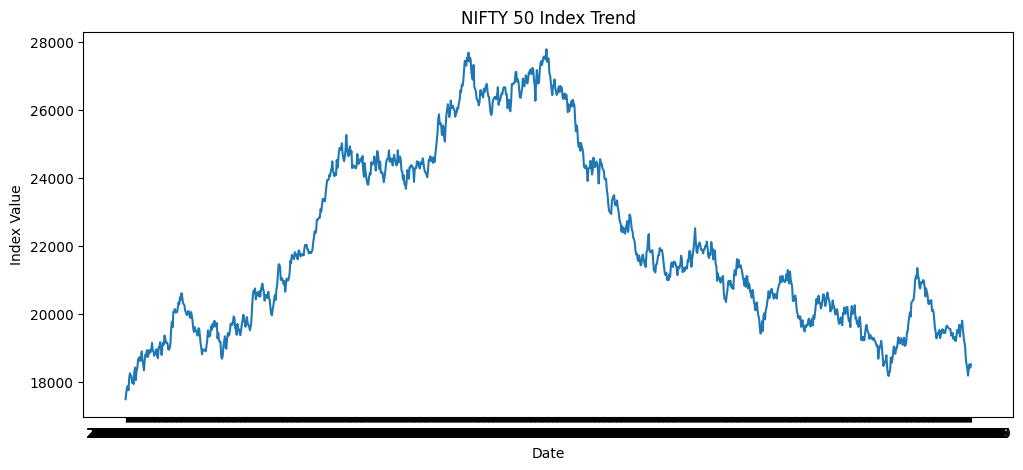

In [38]:
import matplotlib.pyplot as plt

nifty50 = benchmark[
    benchmark["index_name"]=="NIFTY50"
]

plt.figure(figsize=(12,5))

plt.plot(
    nifty50["date"],
    nifty50["close_value"]
)

plt.title("NIFTY 50 Index Trend")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()

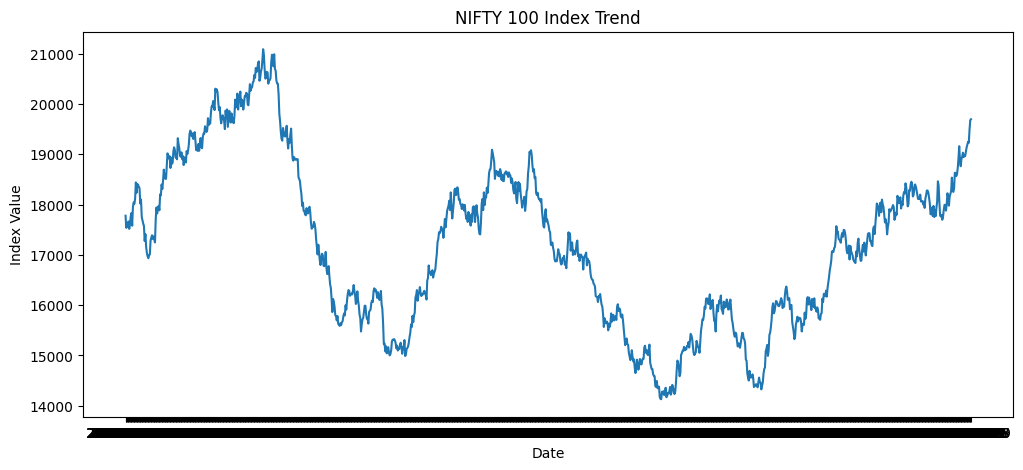

In [39]:
nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
]

plt.figure(figsize=(12,5))

plt.plot(
    nifty100["date"],
    nifty100["close_value"]
)

plt.title("NIFTY 100 Index Trend")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.show()


In [40]:
top5 = (
    performance
    .sort_values(
        "return_3yr_pct",
        ascending=False
    )
    .head(5)
)

top5[
    [
        "scheme_name",
        "return_3yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio"
    ]
]

,scheme_name,return_3yr_pct,alpha,beta,sharpe_ratio
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.23,0.89,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,1.13,1.04,0.93
29,ABSL Small Cap Fund - Regular - Growth,22.38,1.84,0.97,0.90
27,Axis Small Cap Fund - Regular - Growth,20.98,0.51,1.00,0.84
17,Nippon India Small Cap Fund - Regular - Growth,20.15,0.80,1.03,0.81


In [41]:
alpha_beta = performance[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

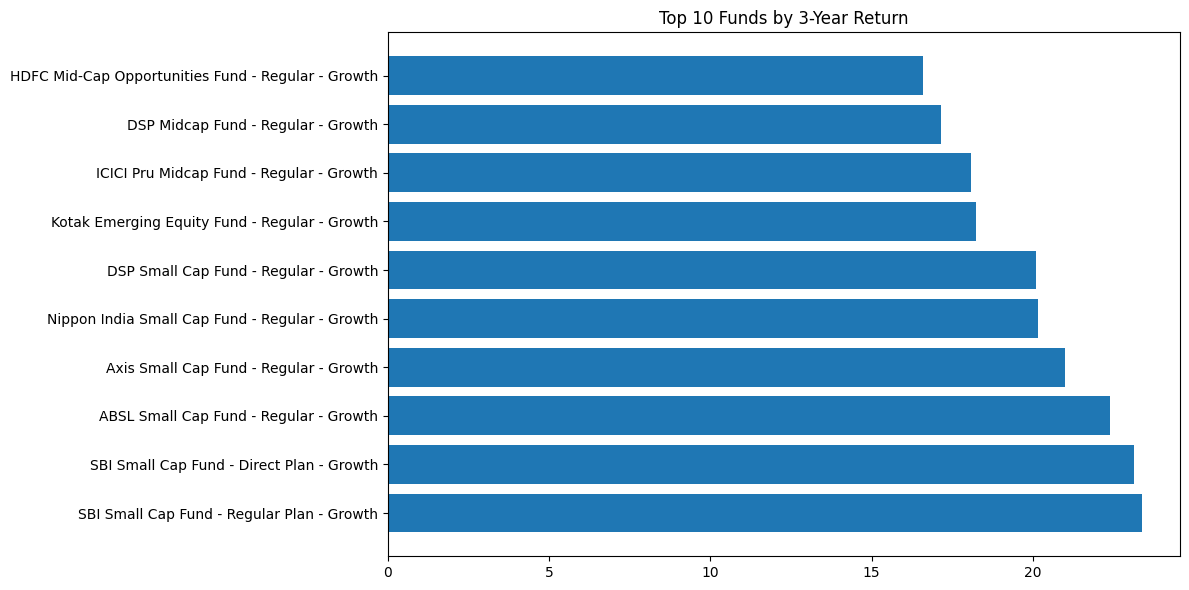

In [42]:
top10 = performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["return_3yr_pct"]
)

plt.title(
    "Top 10 Funds by 3-Year Return"
)

plt.tight_layout()
plt.show()